In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
words=open("names.txt",'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
chars=''.join(words)
chars=sorted(set(chars))
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [ ]:
stoi={s:i+1 for i,s in enumerate(chars)}

In [ ]:
stoi['.']=0

In [ ]:
itos={i:s for s,i in stoi.items()}

In [ ]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [ ]:
import torch
context_size=3
def generatedata(words):
    X=[]
    Y=[]
    for w in words:
        context=[0]*context_size
        for ch in w+".":
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            #print("".join(itos[i] for i in context),"---->",itos[ix])
            context=context[1:]+[ix]
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y

In [ ]:
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=generatedata(words[:n1])
Xval,Yval=generatedata(words[n1:n2])
Xtest,Ytest=generatedata(words[n2:])

In [ ]:
len(stoi)

27

In [ ]:
X.shape


NameError: name 'X' is not defined

In [ ]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [ ]:
Y.shape

torch.Size([228146])

In [ ]:
#C=torch.randn((27,2))

In [ ]:
#C[torch.tensor([2,3,5,5,5,5])]

In [ ]:
#C[[2,4]]

In [ ]:
#C[X].shape

In [ ]:
#X[3,2]

In [ ]:
#C[X][3,2]

In [ ]:
#C[13]

In [ ]:
#emb=C[X]

In [ ]:
#emb.shape

In [ ]:
#W1=torch.randn(6,100)
#b1=torch.randn(100)

In [ ]:
#torch.cat(torch.unbind(emb,1),1) ---> ineffecient way as it requires more memory for contatenation

In [ ]:
#h=torch.tanh(emb.view(-1,6)@W1+b1)

In [ ]:
#h.shape

In [ ]:
#W2=torch.randn((100,27))
#b2=torch.rand(27)

In [ ]:
#logits=h@W2+b2

In [ ]:
#logits.shape

In [ ]:
#counts=logits.exp()

In [ ]:
#prob=counts/counts.sum(1,keepdims=True)

In [ ]:
#prob.shape

In [ ]:
#loss=-prob[torch.arange(32),Y].log().mean()

In [ ]:
#initialize the learnable parameters
g=torch.Generator().manual_seed(1)
vectordim=10
neurons1=200
C=torch.randn((len(stoi),vectordim),generator=g)
W1=torch.randn((vectordim*context_size,neurons1),generator=g)*((5/3)/(vectordim*context_size)**2)
'''
In W1 it is muliplied by the factor of ((5/3)/(vectordim*context_size)**2) because it enables the
output hbact to have same standard deviation as the input "emb". This is particulary useful to
limit the value of hbact in the range of inputs that fall under active regions of tanh and thus
more information is passed through the backward pass. The actual name of this factor is kaiming
initizalization
'''
b1=torch.randn(neurons1,generator=g)*0.02
W2=torch.randn((neurons1,len(stoi)),generator=g)*0.01
b2=torch.randn(len(stoi),generator=g)*0
'''
In W2 and b2 they are scaled to smaller numbers so that when logits are calculated their values are
closer to zero(or rather don't have large deviations) that causes the probabilities to be low and thus
log likelihood loss higher than theoretically possible (for ex. the probability to get a random next
character even in uniform distribution is 1/27 which accounts to loss of 3.22 somethingish) but since
weights are initialzed high and random the probabilities also decreases thereby increasing log likelihood
loss.This causes the neural network to use up many epochs just to compress the weight matrix value which
inherently means to reduce the large loss which is unnecessarily caused due to random and large values of W
matrix
'''
bngain=torch.ones((1,neurons1))
bnbias=torch.zeros((1,neurons1))
parameters=[C,W1,b1,W2,b2,bngain,bnbias]
bmrunning=torch.zeros((1,neurons1))
bstdrunning=torch.ones((1,neurons1))

(array([   4.,   32.,  194.,  751., 1550., 1827., 1184.,  385.,   67.,
           6.]),
 array([-0.00774838, -0.00626934, -0.0047903 , -0.00331126, -0.00183222,
        -0.00035318,  0.00112586,  0.0026049 ,  0.00408393,  0.00556297,
         0.00704201]),
 <BarContainer object of 10 artists>)

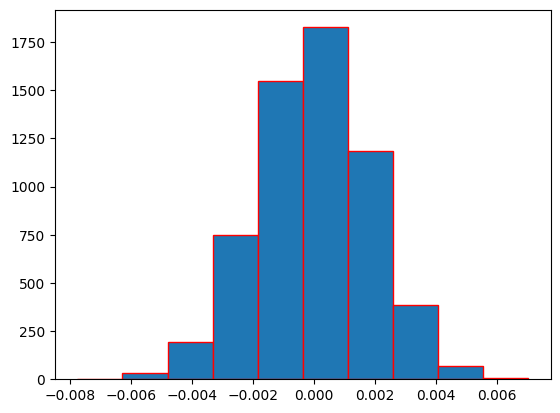

In [ ]:
plt.hist(W1.view(-1).tolist(),ec="red")

In [ ]:
sum(p.nelement() for p in parameters)

12297

In [ ]:

emb=C[Xtr]
h=torch.tanh(emb.view(-1,30)@W1+b1)
logits=h@W2+b2
#counts=logits.exp()
#probs=counts/counts.sum(1,keepdims=True)
#loss=-probs[torch.arange(32),Y].log().mean()
loss=F.cross_entropy(logits,Ytr)#use this because the above approach stores intermediate tensors in the memory but pytorch uses fused kernels to reduce computation overhead
#here the number of features is along the columns and examples is along rows i.e.

(array([  6.,  17., 126., 152., 234., 178., 128.,  57.,  47.,  15.]),
 array([-2.91674256, -2.36925447, -1.82176638, -1.27427828, -0.72679019,
        -0.1793021 ,  0.368186  ,  0.91567409,  1.46316218,  2.01065028,
         2.55813837]),
 <BarContainer object of 10 artists>)

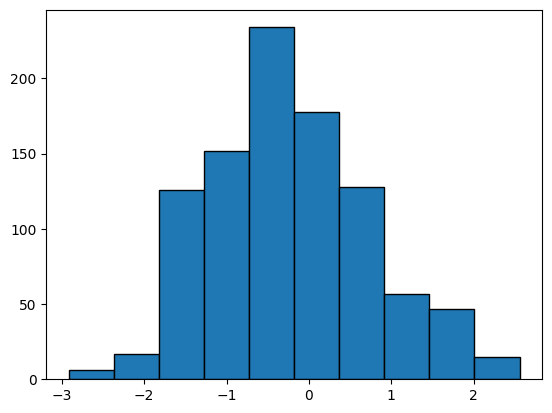

In [ ]:
plt.hist(emb.view(-1).tolist(),ec="black")

In [ ]:
lr=torch.linspace(-3,0,1000)
lri=10**lr


In [ ]:
num_iter=300000
batch_size=32
lre=[]
losse=[]
for p in parameters:
    p.requires_grad=True
for i in range(num_iter):
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))#generating random 32 indexes for a single batch
    emb=C[Xtr[ix]] # embedding+indexing out a batch
    hbact=emb.view(-1,vectordim*context_size)@W1+b1
    bmeani=hbact.mean(0,keepdims=True)
    bstdi=hbact.std(0,keepdims=True)
    hbact=bngain*((hbact-bmeani)/bstdi)+bnbias
    with torch.no_grad():
        bmrunning=0.999*bmrunning+0.001*bmeani
        bstdrunning=0.999*bstdrunning+0.001*bstdi
    '''
    batchnormalization: (here)it normalizes the output hbact into a gaussian curve with mean 0 and standard
    deviation 1(z-normalization) which makes 68 percent of the data to lie between -1 and 1 which is the range where the
    tanh function is active( i.e while doing back propagation some information is passed through the tanh
    node).furthermore bngain and bnbias are also added which makes the neural network more flexible so that
    it is not limited to learning just the standard normal curve but also flexible enough to adjust the
    mean and standard deviation accordingly.As the network becomes deeper different operations are performed
    and the feasibility to multiply the weights by a factor such that a neural network layers output will be
    gaussian is less effecient than just using batch normailization.
    It also acts a regularizer because different batches have different mean and starndard deviation and thus
    hbact jitters (might have different normalization for different batches)thus it is harder for the network
    to overfit the data
    '''
    h=torch.tanh(hbact)
    logits=h@W2+b2
    loss=F.cross_entropy(logits,Ytr[ix])
    #print(loss.item())
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data-=p.grad*0.1
    #losse.append(loss.item())
    #lre.append(lri[i])

(array([458., 225., 197., 165., 130., 122., 127.,  99., 105., 109., 104.,
         93., 104.,  90.,  79.,  88.,  87., 101., 115.,  91.,  90., 102.,
         90., 112., 124., 130.,  92., 116.,  75.,  91.,  88., 109.,  91.,
         70., 104.,  74.,  79., 100., 106., 114., 109., 126., 107., 137.,
        120., 141., 152., 201., 212., 449.]),
 array([-1.00000000e+00, -9.60002148e-01, -9.20004296e-01, -8.80006444e-01,
        -8.40008593e-01, -8.00010741e-01, -7.60012889e-01, -7.20015037e-01,
        -6.80017185e-01, -6.40019333e-01, -6.00021482e-01, -5.60023630e-01,
        -5.20025778e-01, -4.80027926e-01, -4.40030074e-01, -4.00032222e-01,
        -3.60034370e-01, -3.20036519e-01, -2.80038667e-01, -2.40040815e-01,
        -2.00042963e-01, -1.60045111e-01, -1.20047259e-01, -8.00494075e-02,
        -4.00515556e-02, -5.37037849e-05,  3.99441481e-02,  7.99419999e-02,
         1.19939852e-01,  1.59937704e-01,  1.99935555e-01,  2.39933407e-01,
         2.79931259e-01,  3.19929111e-01,  3.59926

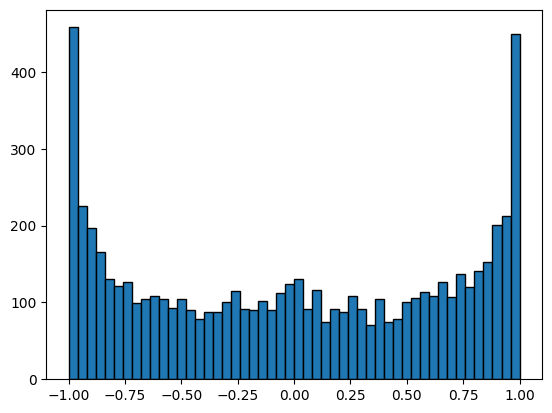

In [ ]:
plt.hist(h.view(-1).tolist(),50,ec="black")

tensor(0.0151, grad_fn=<MeanBackward0>) tensor(1.0169, grad_fn=<StdBackward0>)


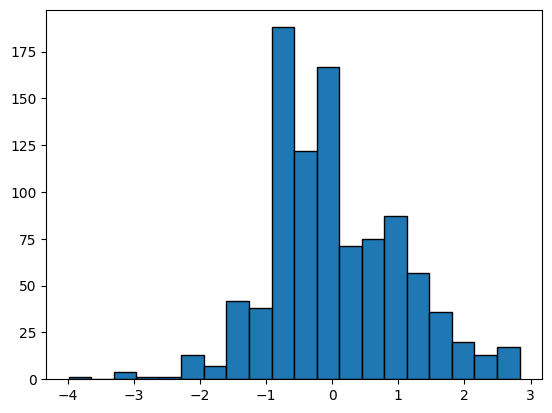

In [ ]:
plt.hist(emb.view(-1).tolist(),20,ec="black")
print(emb.mean(),emb.std())

tensor(-0.0139, grad_fn=<MeanBackward0>) tensor(1.3456, grad_fn=<StdBackward0>)


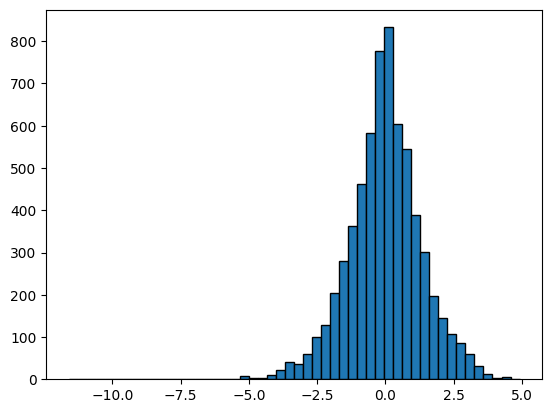

In [ ]:
plt.hist(hbact.view(-1).tolist(),50,ec="black")
print(hbact.mean(),hbact.std())

In [ ]:
logits.max(1)

torch.return_types.max(
values=tensor([-0.3246,  4.8300,  2.2059,  6.0651,  1.6787,  0.4990,  6.4367,  7.9853,
         6.3561, -0.6664, -1.5029, -1.8825,  9.5697,  2.7296,  0.4990,  1.0211,
         5.7734,  2.0377, -0.4998,  1.2121, -1.0424,  2.0377,  3.8231,  3.2263,
         2.4388,  2.0954,  0.7784, -1.5029,  1.5648, -1.9176, -1.5029,  3.8231],
       grad_fn=<MaxBackward0>),
indices=tensor([13,  9,  0,  9, 20, 13,  1,  1,  5, 14, 13, 14,  1,  9, 13, 14,  1, 15,
        18,  1, 14, 15, 15, 14, 14,  9, 12, 13, 14, 14, 13, 15]))

In [ ]:
torch.randint(0,X.shape[0],(32,))

NameError: name 'X' is not defined

In [ ]:
emb=C[Xtr]
h=torch.tanh(emb.view(-1,30)@W1+b1)
logits=h@W2+b2
loss=F.cross_entropy(logits,
                     Ytr
                     )
print(loss.item())

2.8665177822113037


In [ ]:
import matplotlib.pyplot as plt


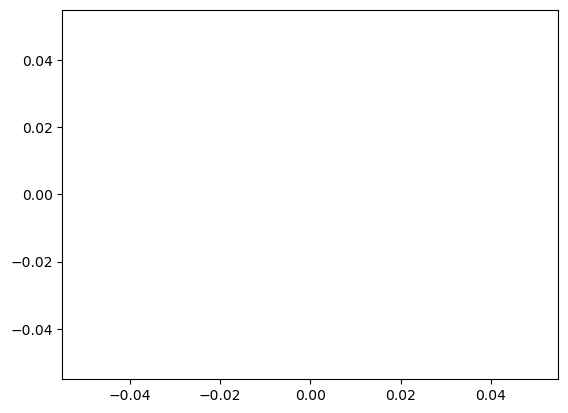

In [ ]:
plt.plot(lre,losse)

In [ ]:

g=torch.Generator().manual_seed(2117483647)
for i in range(30):
    out=[]
    context=[0]*3
    while True:
        emb=C[torch.tensor(context)]
        hbact=emb.view(-1,vectordim*context_size)@W1+b1
        hbact=bngain*((hbact-bmrunning)/bstdrunning)+bnbias
        '''
        Since we were normalizing hbact with respect to mean and std of respect batches but during inference
        a single training example might be the input. So after the above step the hbact will likely be zero
        due to cancelling out of the hbact and hbact.mean() (i.e hbact.mean() over a single example has same
        value as that example). So we require to calculate an appropriate mean and std from the training set
        There are two options either to calculate the mean and std of whole training set after training the
        network separately or to take exponentially weighted averages of the mean and std during the training
        itself
        '''
        h=torch.tanh(hbact)
        logits=h@W2+b2
        prob=F.softmax(logits,dim=1)
        #print(prob.shape)
        ix=torch.multinomial(prob,num_samples=1,generator=g).item()
        context=context[1:]+[ix]
        out.append(ix)
        if ix==0:
            break
    print(''.join(itos[i] for i in out))

ladiana.
malieglon.
marie.
may.
mavington.
sadaytasyia.
reanna.
adda.
noa.
breen.
sawynn.
sariyiah.
baxlinn.
shadis.
addell.
scheet.
kaleighton.
aluy.
ckyn.
nowen.
ajahni.
emiyonnalin.
lay.
romarrishudan.
hahyla.
ima.
alne.
kark.
aurzah.
aurin.


In [ ]:
a=torch.randn(50)

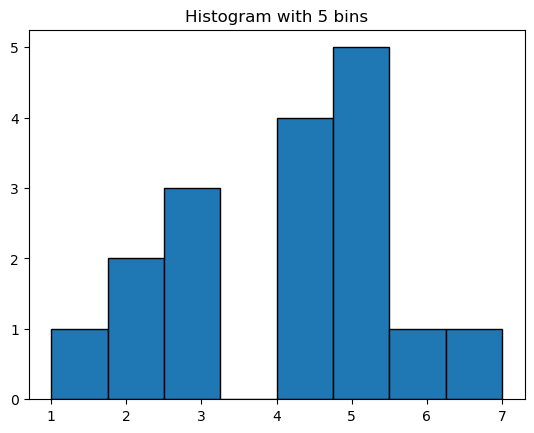

In [ ]:
import matplotlib.pyplot as plt

data = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5,6,7]

# Use 5 bins
plt.hist(data, bins=8, edgecolor='black')
plt.title('Histogram with 5 bins')
plt.show()
